# Plot of the 3 different regimes (under-coupled, critical, over-coupled) with theory

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Theoretical data

In [27]:
def S11(omega, omega_0, kappa_c, kappa_t):
    
    return 1 - kappa_c / ((kappa_t/2) + 1j * (omega - omega_0))

In [54]:
f0 = 6e+09
bandwidth = 500e+06
freq = np.linspace(f0 - bandwidth/2, f0 + bandwidth/2, 1001)
kappa_i = 100e+06

kappa_c_under = 50e+06
S11_under = S11(freq * (2*np.pi), f0 * (2*np.pi), kappa_c_under, kappa_i + kappa_c_under)

kappa_c_critic = 100e+06
S11_critic = S11(freq * (2*np.pi), f0 * (2*np.pi), kappa_c_critic, kappa_i + kappa_c_critic)

kappa_c_over = 500e+06
S11_over = S11(freq * (2*np.pi), f0 * (2*np.pi), kappa_c_over, kappa_i + kappa_c_over)

In [41]:
def convert_S11(S11_values):
    
    mag = 20 * np.log10(np.abs(S11_values))
    arg = np.angle(S11_values)
    re = np.real(S11_values)
    im = np.imag(S11_values)
    
    return {'re': re,
            'im': im,
            'mag': mag,
            'arg': arg}

In [55]:
under = convert_S11(S11_under)

critic = convert_S11(S11_critic)

over = convert_S11(S11_over)

/tmp/ipykernel_1249/2622068766.py:3: RuntimeWarning: divide by zero encountered in log10
  mag = 20 * np.log10(np.abs(S11_values))


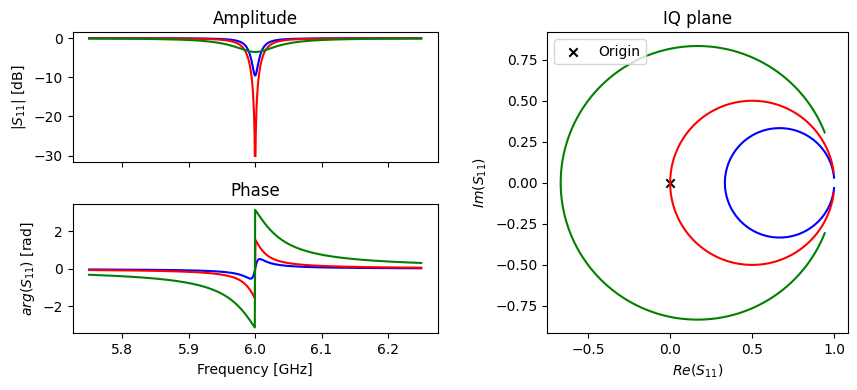

In [76]:
fig = plt.figure(figsize=(9, 4))
gs = gridspec.GridSpec(2, 4)

ax_mag = fig.add_subplot(gs[0, 0:2])
ax_arg = fig.add_subplot(gs[1, 0:2])
ax_IQ = fig.add_subplot(gs[:, 2:4])

ax_mag.plot(freq, under['mag'], color='blue', linestyle='-', label='Under-coupled')
ax_mag.plot(freq, critic['mag'], color='red', linestyle='-', label='Critically coupled')
ax_mag.plot(freq, over['mag'], color='green', linestyle='-', label='Over-coupled')

ax_mag.set_xticklabels([])
ax_mag.set_ylabel('$|S_{11}|$ [dB]')
ax_mag.set_title('Amplitude')

ax_arg.plot(freq * 1e-09, under['arg'], color='blue', linestyle='-', label='Under-coupled')
ax_arg.plot(freq * 1e-09, critic['arg'], color='red', linestyle='-', label='Critically coupled')
ax_arg.plot(freq * 1e-09, over['arg'], color='green', linestyle='-', label='Over-coupled')

ax_arg.set_xlabel('Frequency [GHz]')
ax_arg.set_ylabel('$arg(S_{11})$ [rad]')
ax_arg.set_title('Phase')

ax_IQ.plot(under['re'], under['im'], color='blue', linestyle='-')
ax_IQ.plot(critic['re'], critic['im'], color='red', linestyle='-')
ax_IQ.plot(over['re'], over['im'], color='green', linestyle='-')
ax_IQ.scatter([0], [0], color='black', marker='x', label='Origin')

ax_IQ.set_aspect('equal')
ax_IQ.set_xlabel('$Re(S_{11})$')
ax_IQ.set_ylabel('$Im(S_{11})$')
ax_IQ.set_title('IQ plane')
ax_IQ.legend()
fig.tight_layout()

    